<a href="https://colab.research.google.com/github/maxwellfundi/ADIWebsite/blob/master/Final_work_Njiru_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installing Faker package - a Python package that allows you to generate fake data

In [ ]:
# Installing Faker

!pip install Faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 40.8 MB/s eta 0:00:00


Use faker to generate fake data with 2000 rows and export it to Excel

In [ ]:
import pandas as pd
import random
from faker import Faker

# Initialize Faker instance
fake = Faker()

# Define list of products
products = ['Onions', 'Potatoes', 'Tomatoes', 'Bananas', 'Apples']

# Generate data for 2000 random individuals
individuals = []
for _ in range(2000):
    name = fake.name()
    city = fake.city()
    country = fake.country()
    sex = random.choice(['Male', 'Female'])
    age = random.randint(18, 80)
    feedback_count = random.randint(1, len(products))
    feedback = [fake.text(max_nb_chars=200) for _ in range(feedback_count)]
    individuals.append((name, city, country, sex, age, feedback))

# Generate net revenue for each product feedback
def generate_net_revenue():
    if random.random() < 0.05:
        return random.randint(10000, 50000)  # Outlier
    else:
        return random.randint(100, 10000)

# Create DataFrame
columns = ['Name', 'City', 'Country', 'Sex', 'Age', 'Feedback', 'Product', 'Net Revenue', 'Date']
data = []
for individual in individuals:
    name, city, country, sex, age, feedback = individual
    for prod in random.sample(products, len(feedback)):
        net_revenue = generate_net_revenue()
        data.append((name, city, country, sex, age, feedback.pop(), prod, net_revenue, fake.date_this_decade()))

df = pd.DataFrame(data, columns=columns)

# Save to Excel file
output_file = 'Final_work_Njiru.xlsx'
df.to_excel(output_file, index=False)

print(f"Generated data saved to {output_file}.")

Generated data saved to Final_work_Njiru.xlsx.


Carrying out descriptive statistics


In [ ]:
#Imports and loading data

import pandas as pd
df = pd.read_excel('Final_work_Njiru.xlsx')

In [ ]:
#descriptive statistics
df.describe()

,Age,Net Revenue,Date
count,6040.000000,6040.000000,6040
mean,49.223675,6099.989901,2022-05-22 22:39:10.728476928
min,18.000000,101.000000,2020-01-01 00:00:00
25%,34.000000,2756.750000,2021-03-12 18:00:00
50%,50.000000,5332.000000,2022-05-11 00:00:00
75%,64.000000,7826.500000,2023-08-05 00:00:00
max,80.000000,49852.000000,2024-10-15 00:00:00
std,18.153267,6108.391636,NaN


In [ ]:
descriptive_stats = df.describe(include='all')
descriptive_stats.to_excel('descriptive_stats.xlsx', sheet_name='Statistics')

Working on associations

In [ ]:
#install sweetviz -Python library that generates beautiful, high-density visualizations to kickstart EDA (Exploratory Data Analysis)
!pip install sweetviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 88.2 MB/s eta 0:00:00


                                             |          | [  0%]   00:00 -> (? left)


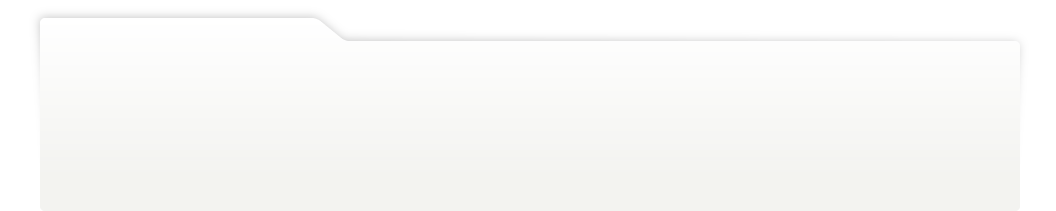
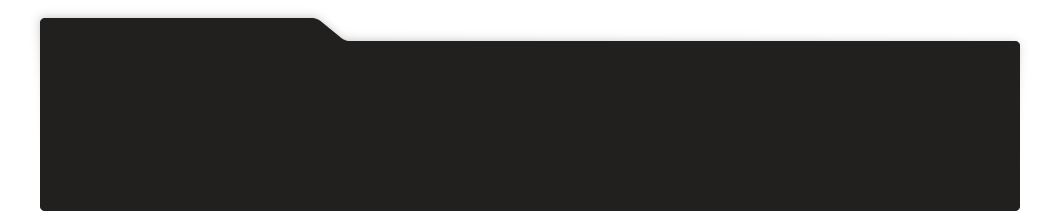
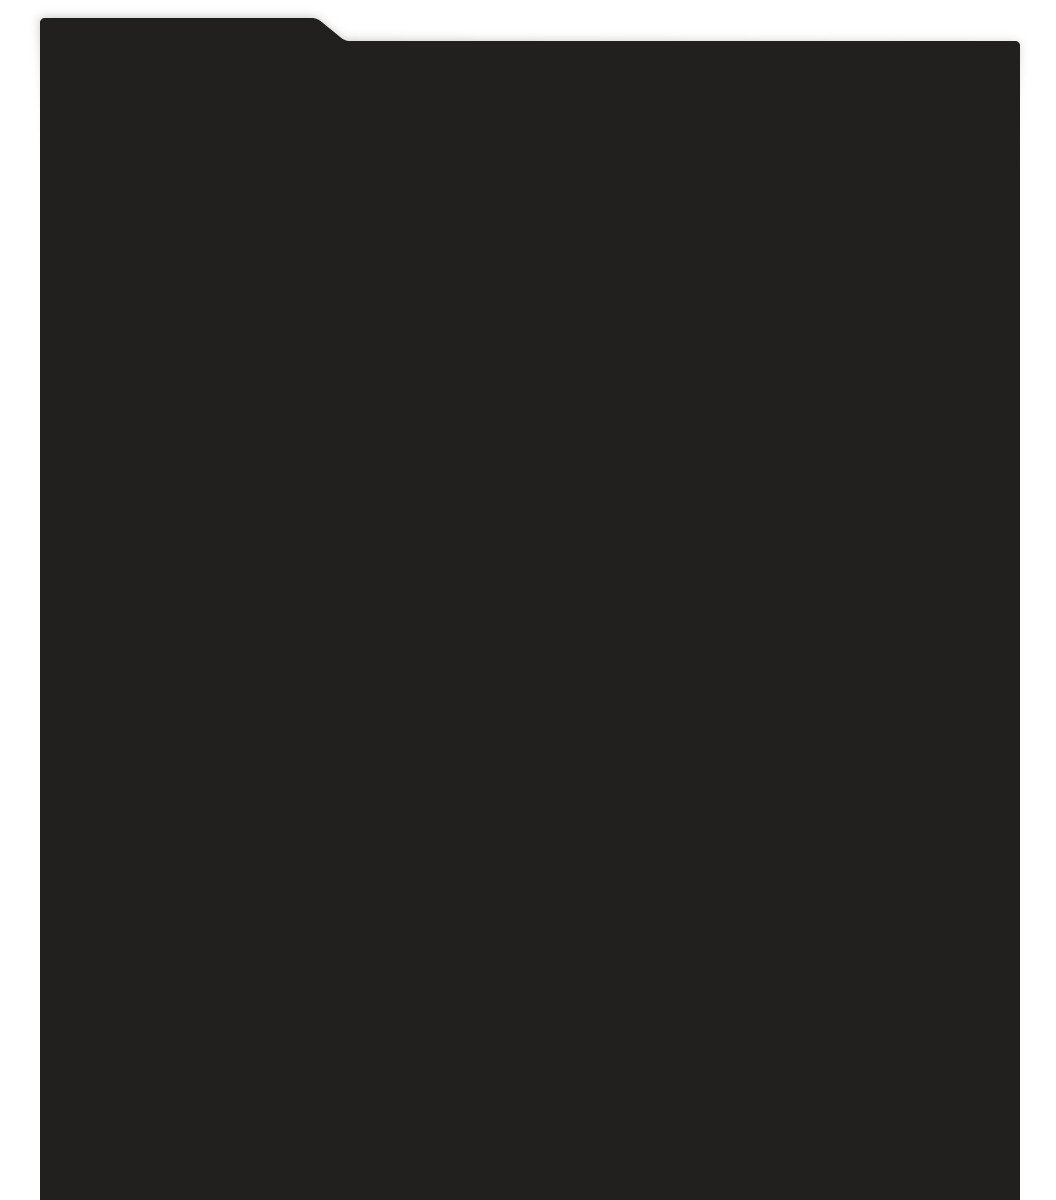
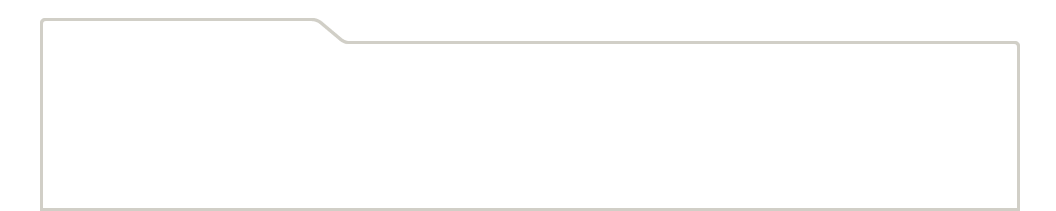
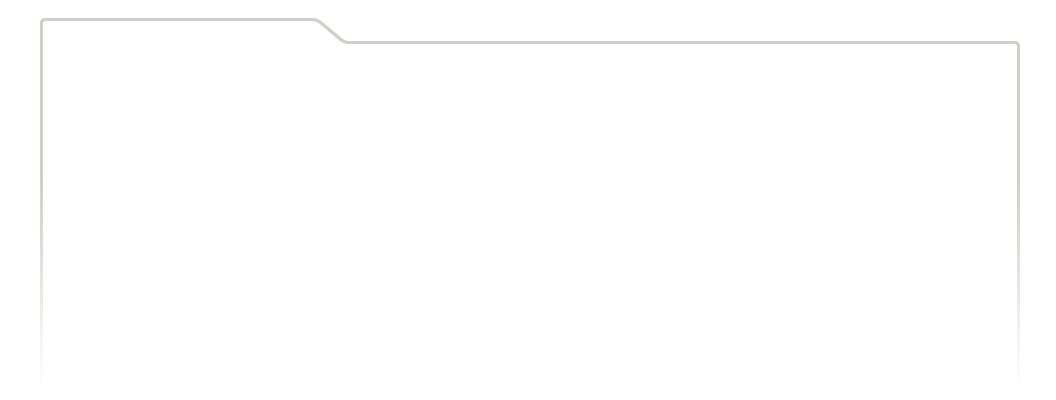
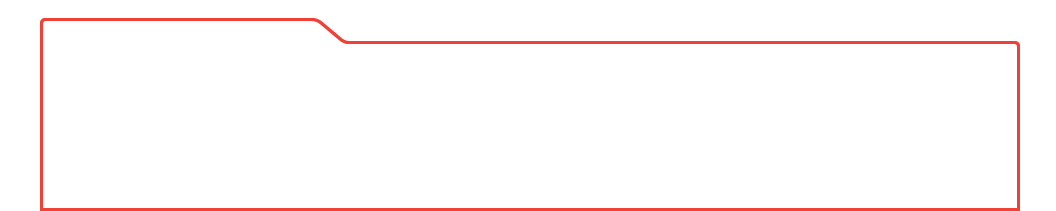
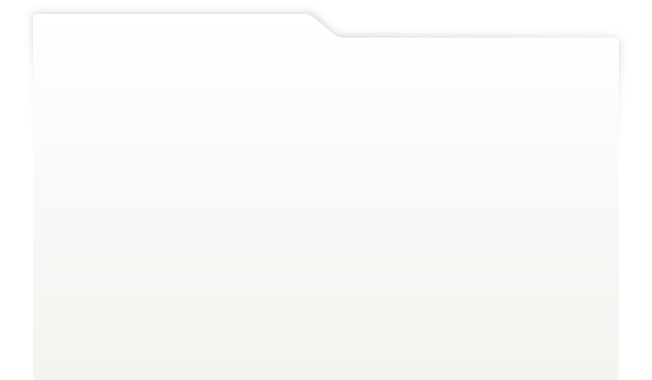
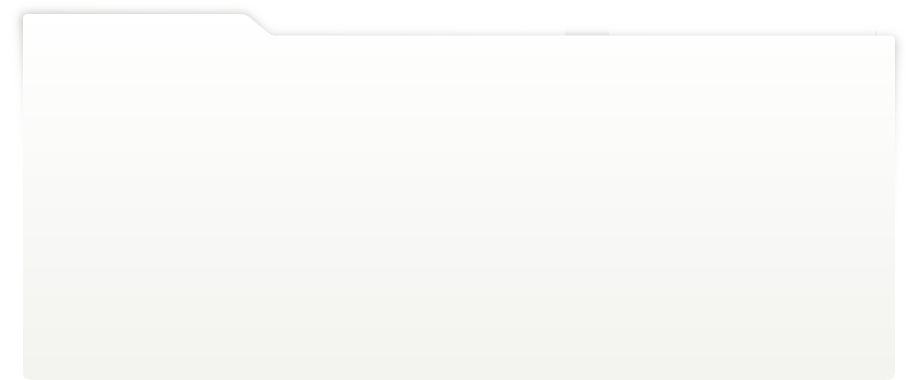
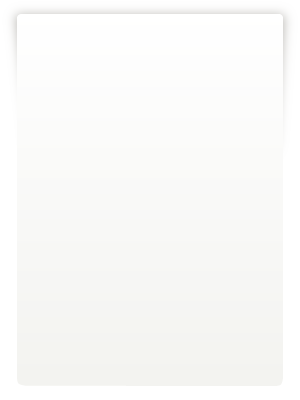
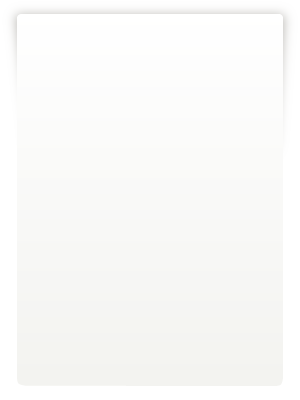
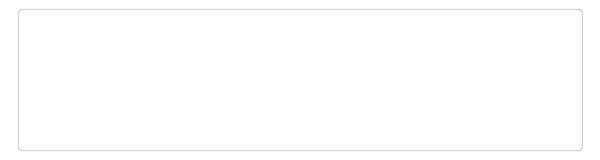
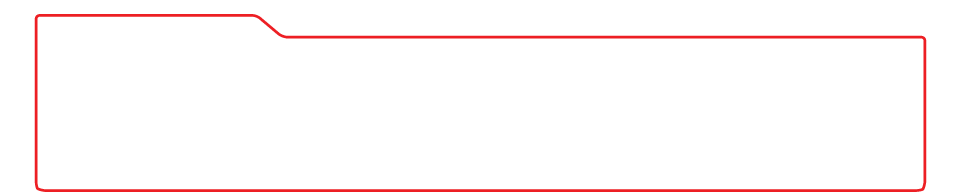
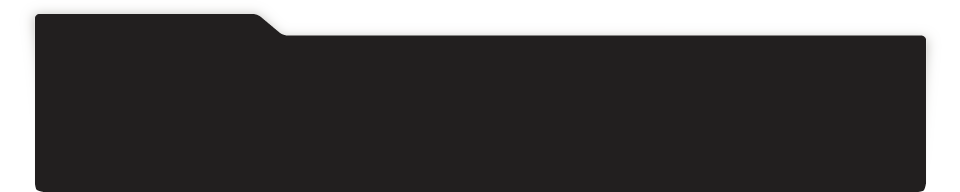
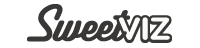
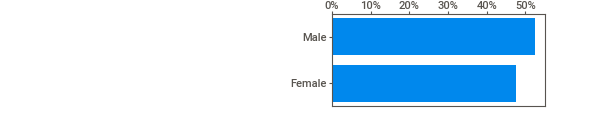
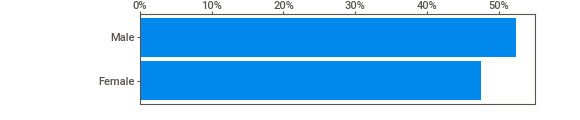
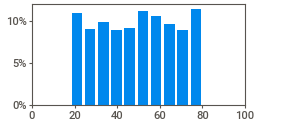
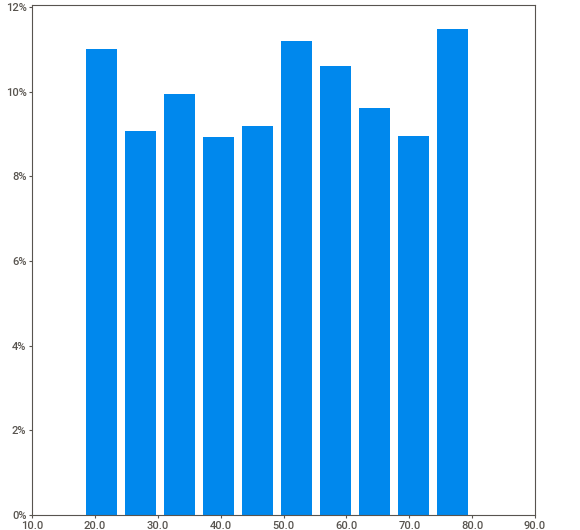
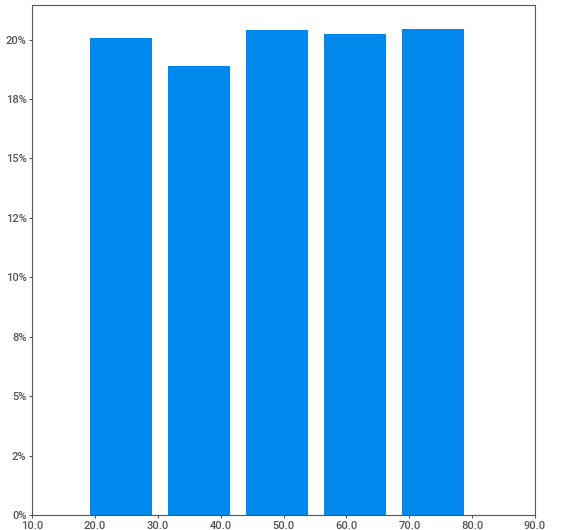
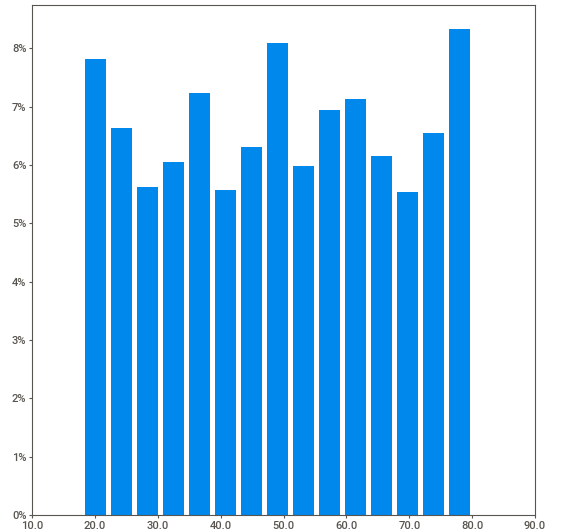
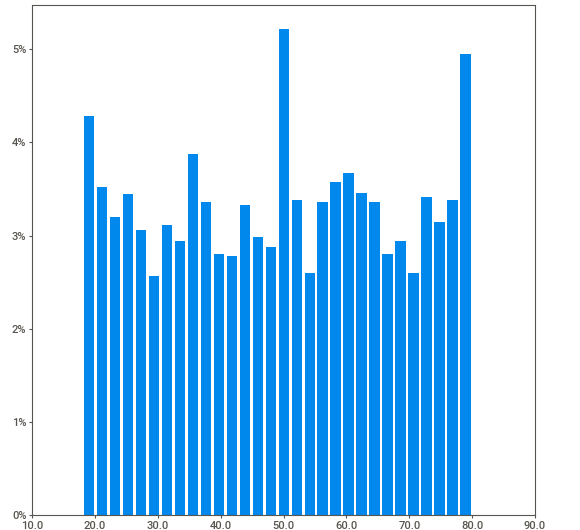
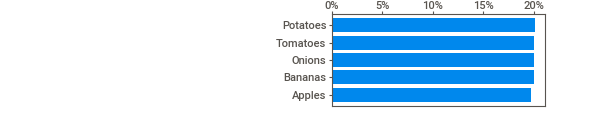
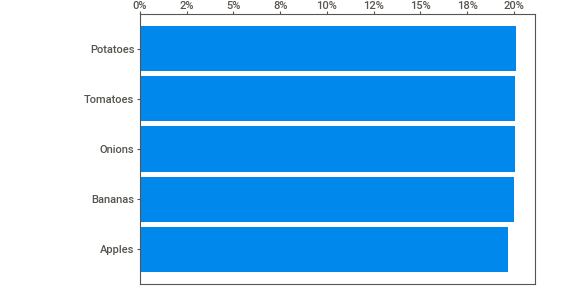
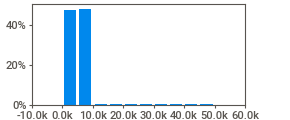
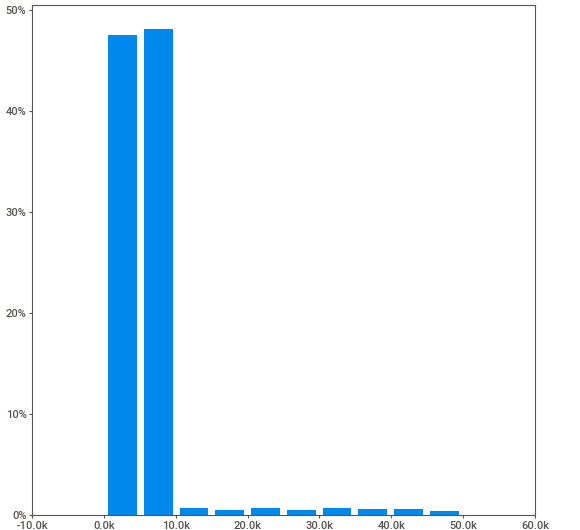
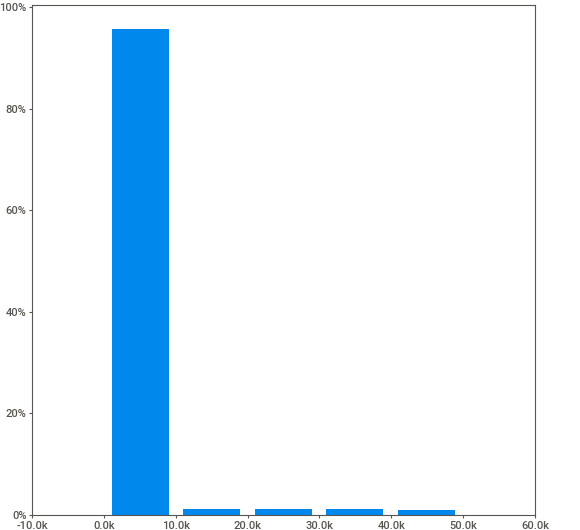
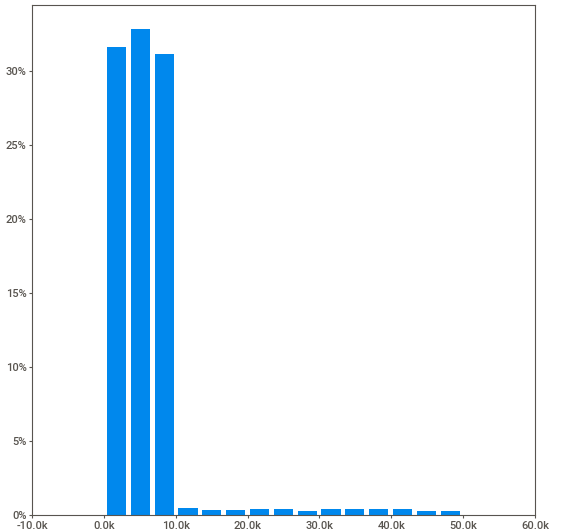
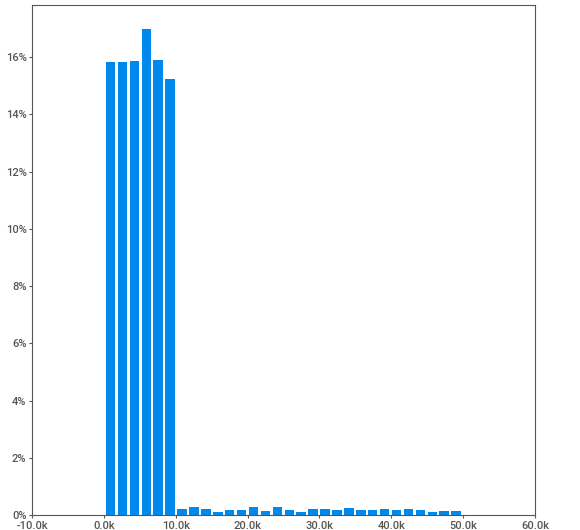
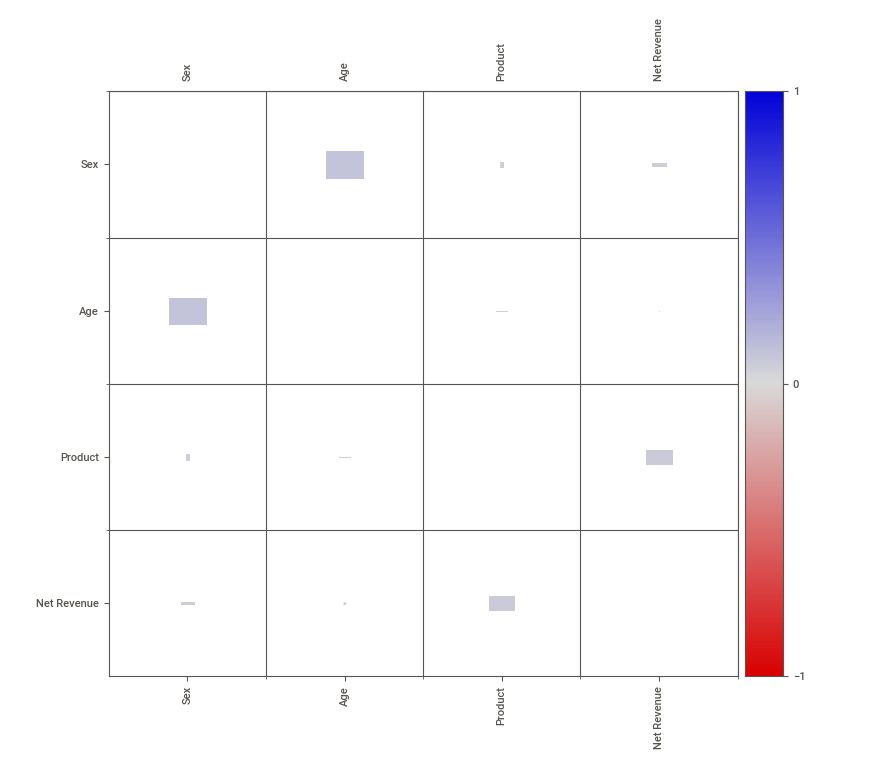
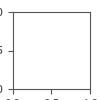

Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [ ]:
import sweetviz as sv
report = sv.analyze(df)
report.show_notebook()
report.show_html('sweetviz_report.html')

generate a boxplot

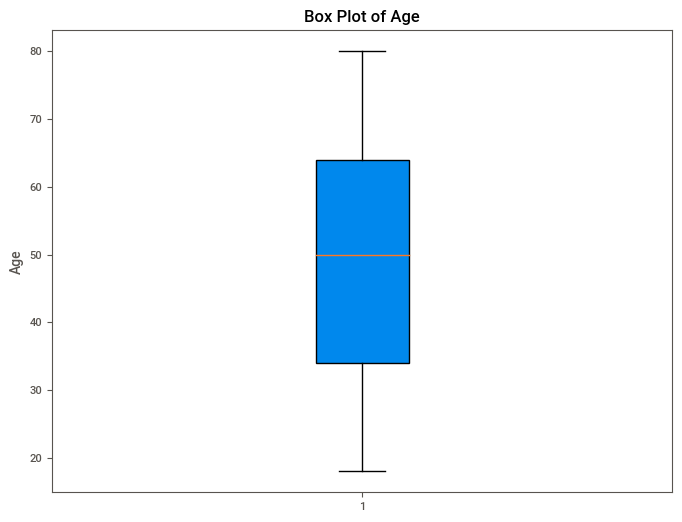

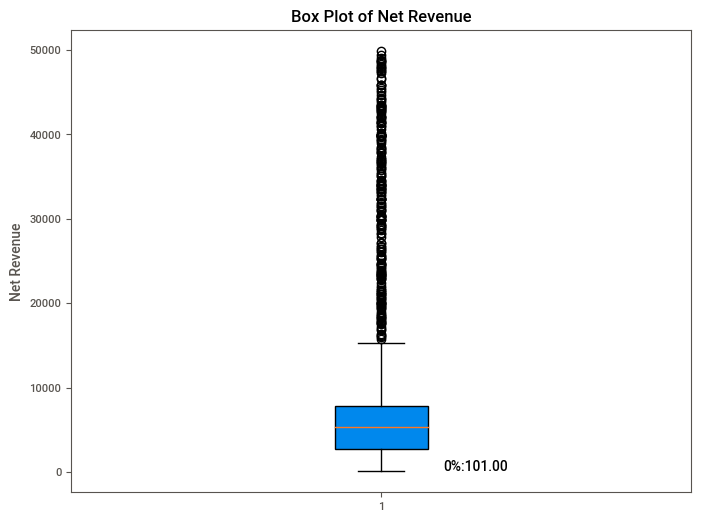

ValueError: Image size of 671x1018945 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 671x1970757 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 671x2892725 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 687x18425349 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Iterate through numerical columns
for column in df.select_dtypes(include=np.number).columns:
# Calculate percentiles
  percentiles = [0, 25, 50, 75, 100]
  percentile_values = np.percentile(df[column], percentiles)
 # Create a box plot
  plt.figure(figsize=(8, 6))
  plt.boxplot(df[column], vert=True, patch_artist=True)
  plt.title(f'Box Plot of {column}')
  plt.ylabel(column)
 # Add percentile labels
for i, percentile in enumerate(percentiles):
 plt.text(1.1, percentile_values[i], f'{percentile}%:{percentile_values[i]:.2f}')
 plt.show()

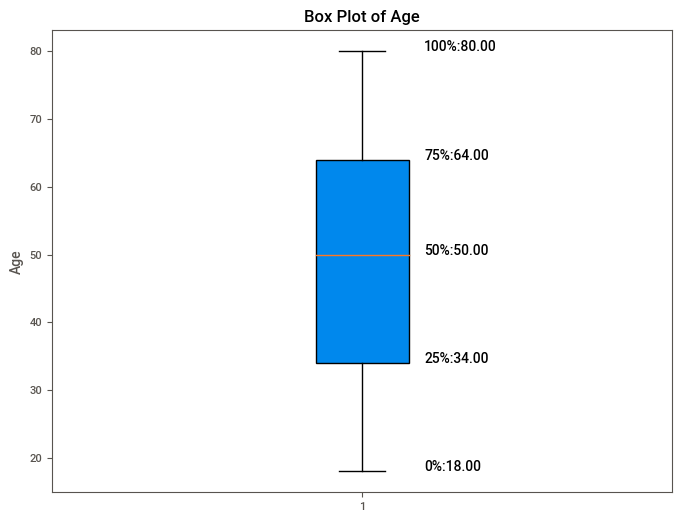

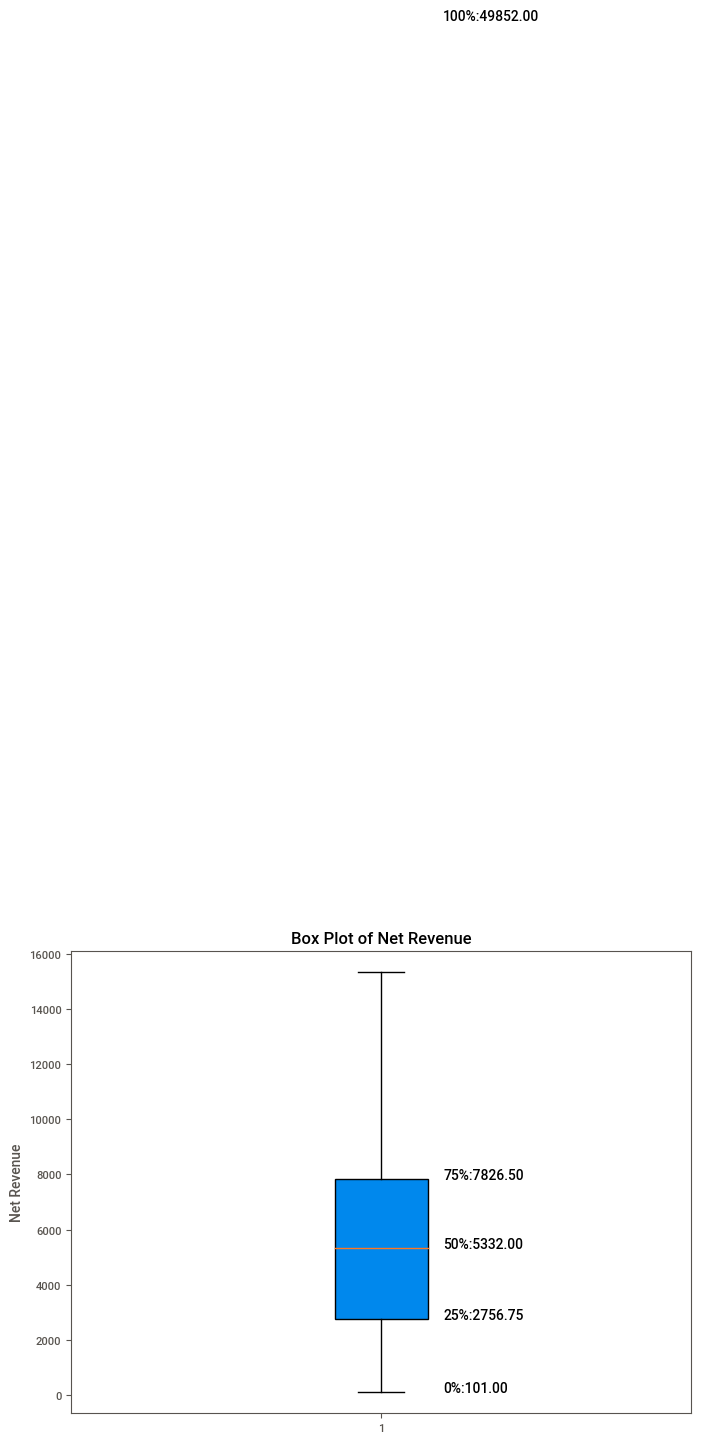

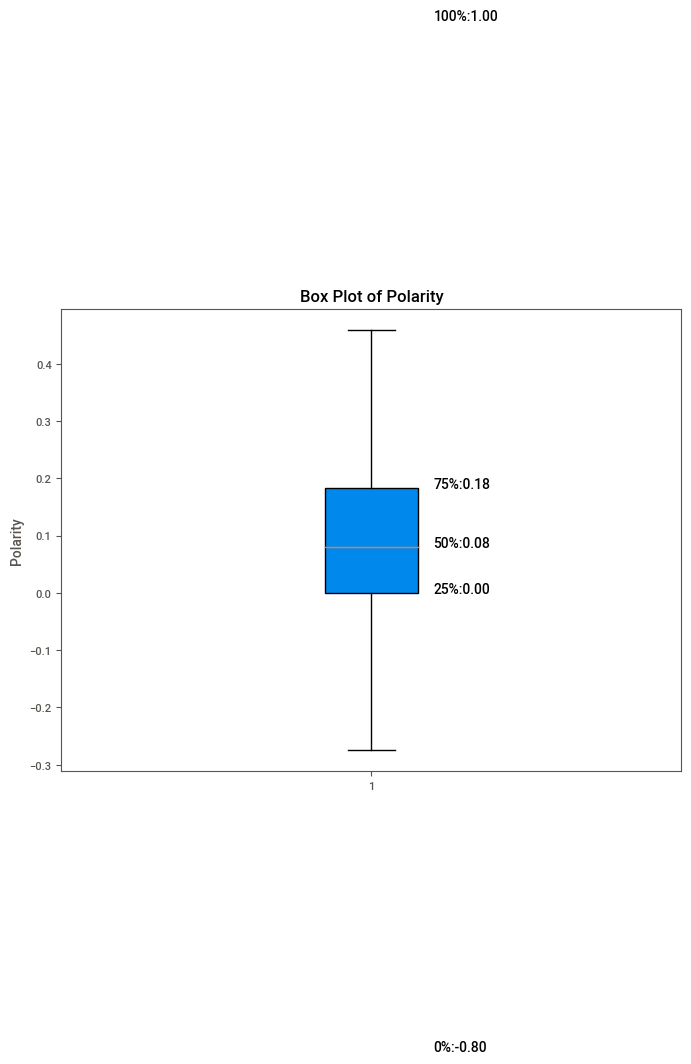

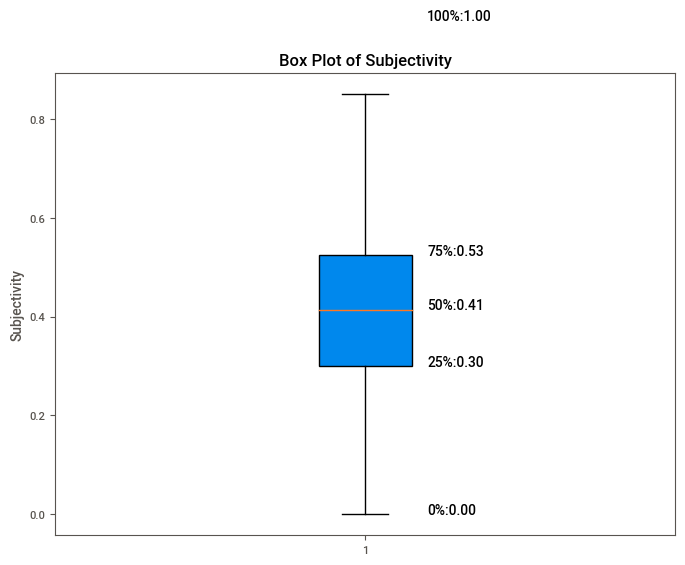

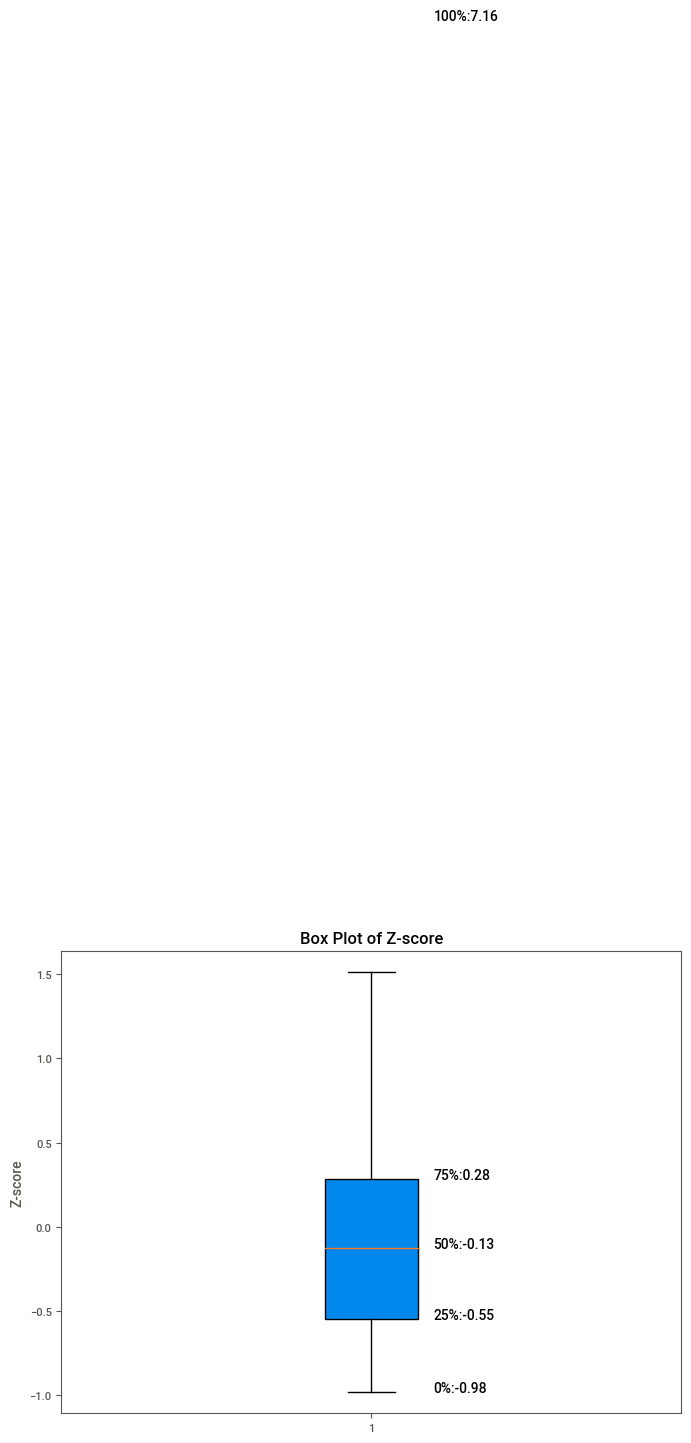

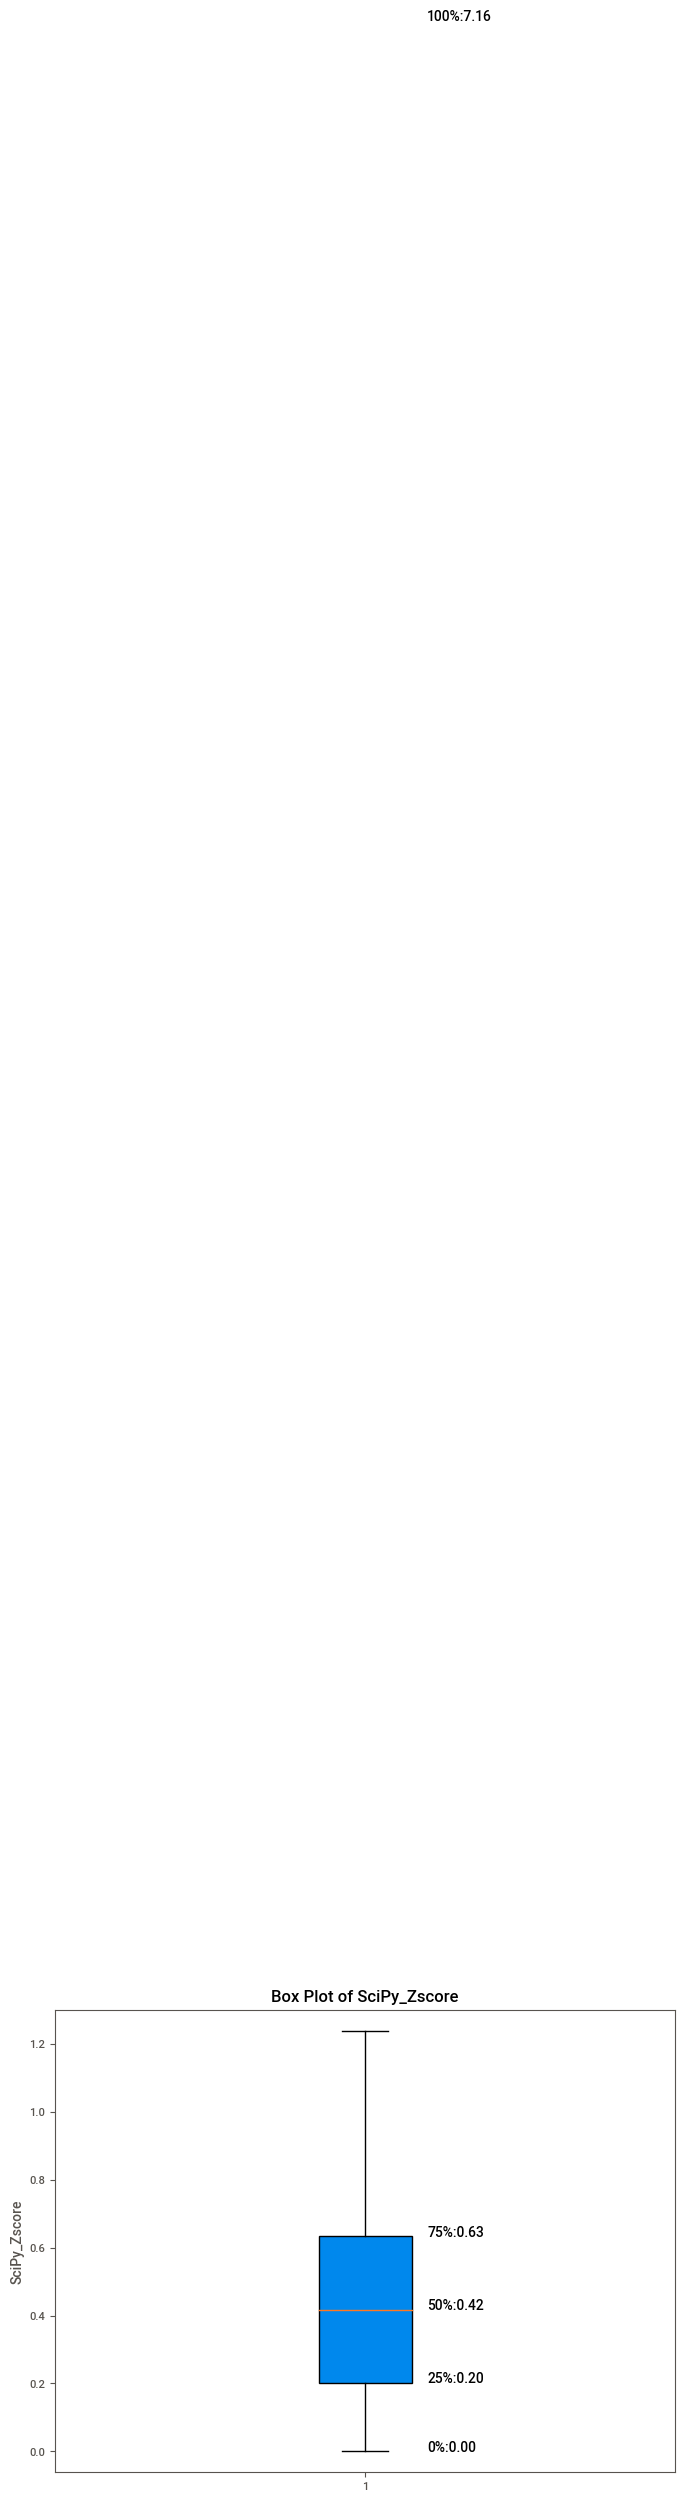

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Iterate through numerical columns
for column in df.select_dtypes(include=np.number).columns:
    # Calculate percentiles
    percentiles = [0, 25, 50, 75, 100]
    percentile_values = np.percentile(df[column], percentiles)

    # Create a box plot
    plt.figure(figsize=(8, 6))

    # Handle outliers by setting 'showfliers' to False or using a custom range
    plt.boxplot(df[column], vert=True, patch_artist=True, showfliers=False)  # Hide outliers
    # Alternatively, set the y-axis limits manually:
    # plt.ylim(percentile_values[0], percentile_values[4])

    plt.title(f'Box Plot of {column}')
    plt.ylabel(column)

    # Add percentile labels
    for i, percentile in enumerate(percentiles):
        plt.text(1.1, percentile_values[i], f'{percentile}%:{percentile_values[i]:.2f}')

    plt.show()

Explore outliers using IQR (Interquartile Range)

In [ ]:
import pandas as pd
import numpy as np

#Calculate the IQR for Net Revenue
Q1 = df['Net Revenue'].quantile(0.25)
Q3 = df['Net Revenue'].quantile(0.75)
IQR = Q3 - Q1

#Define the lower and upper bounds for outliers
lower_bound_iqr = Q1 - 1.5 * IQR
upper_bound_iqr = Q3 + 1.5 * IQR

#Create a new column to indicate whether a row is an outlier or not
df['Outlier_IQR'] = np.where((df['Net Revenue'] < lower_bound_iqr) |
 (df['Net Revenue'] > upper_bound_iqr), 'Outlier', 'Not Outlier')

df.to_excel('IQR.xlsx', index=False)

Explore outliers using Z scores using Pandas

In [ ]:
import pandas as pd
import numpy as np
# Calculate the Z-score for Net Revenue
mean = df['Net Revenue'].mean()
std = df['Net Revenue'].std()
df['Z-score'] = (df['Net Revenue'] - mean) / std
# Define the threshold for outliers based on Z-score
threshold = 3

# Create a new column to indicate whether a row is an outlier or not
df['Outlier_Zscore'] = np.where(abs(df['Z-score']) > threshold, 'Outlier', 'Not Outlier')

df.to_excel('zscores.xlsx', index=False)

Explore outliers using Z scores using SciPY

In [ ]:
import numpy as np
from scipy import stats
# Calculate the z-scores for 'Net Revenue'
df['SciPy_Zscore'] = np.abs(stats.zscore(df['Net Revenue']))
# Define a threshold for identifying outliers (e.g., z-score > 3)
threshold = 3
# Identify outliers based on the z-score method
outliers_zscore = df[df['SciPy_Zscore'] > threshold]
# Create a new column to indicate whether a row is an outlier or not
df['Outliers_SpiCy_z'] = np.where(abs(df['SciPy_Zscore']) > threshold, 'Outlier', 'Not Outlier')

df.to_excel('spicy.xlsx', index=False)

Explore column profiles

In [ ]:
# install ydata-profiling - package for data profiling, that automates and standardizes the generation of detailed reports, complete with statistics and visualizations.
!pip install ydata-profiling


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 356.2/356.2 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 686.1/686.1 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.8/104.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 58.2 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=36499e00f98c1bf84d52769788fe5b32a3b9da6415f987292e3cc0c6e06294c4
  Stored in directory: /root/.cache/pip/wheels/dd/91/29/a79cecb328d01739e64017b6fb9a1ab9d8cb1853098ec5966d
Successfully built htmlmin


In [ ]:
import pandas as pd
from ydata_profiling import ProfileReport
# Assuming 'df' is your pandas DataFrame
profile = ProfileReport(df, title="Pandas Profiling Report")
# Generate the report
# profile.to_file("Ydata.html")
# You can also display it in the notebook:
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Text insights - Explore words using a word cloud

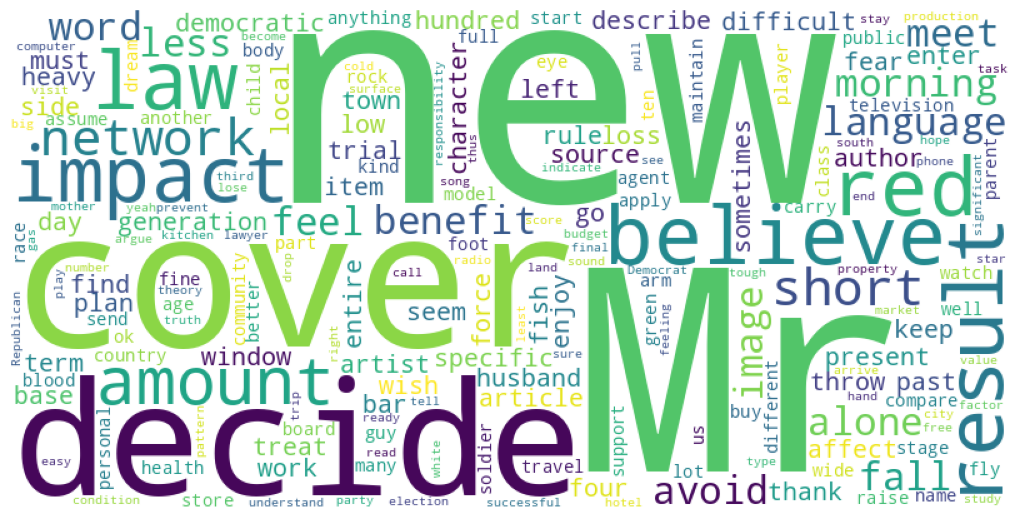

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
# Assuming 'Feedback' is the column name containing the feedback text
feedback_text = ' '.join(df['Feedback'].astype(str))
# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(feedback_text)
# Display the generated image:
plt.figure(figsize=(10, 5), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()


Explore feedbacks

In [ ]:
from textblob import TextBlob

def analyze_feedback(feedback):
    analysis = TextBlob(feedback)
    return analysis.sentiment.polarity, analysis.sentiment.subjectivity

# Assuming 'Feedback' is the column name containing the feedback text
df['Polarity'], df['Subjectivity'] = zip(*df['Feedback'].apply(analyze_feedback))

def label_feedback(row):
    if row['Polarity'] > 0 and row['Subjectivity'] > 0.5:
        return 'Positive & Subjective'
    elif row['Polarity'] > 0 and row['Subjectivity'] <= 0.5:
        return 'Positive & Objective'
    elif row['Polarity'] == 0 and row['Subjectivity'] > 0.5:
        return 'Neutral & Subjective'
    elif row['Polarity'] == 0 and row['Subjectivity'] <= 0.5:
        return 'Neutral & Objective'
    elif row['Polarity'] < 0 and row['Subjectivity'] > 0.5:
        return 'Negative & Subjective'
    else:
        return 'Negative & Objective'

df['Feedback_Label'] = df.apply(label_feedback, axis=1)



Clustering and forecasting

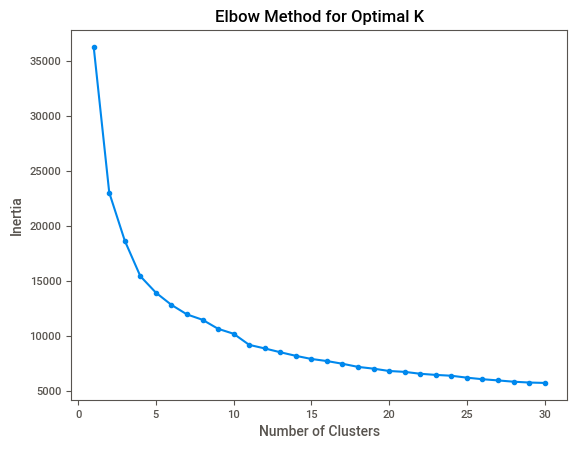

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt  # Import for plotting

# Select only numerical columns for clustering
numerical_df = df.select_dtypes(include=np.number)

# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numerical_df)

# Find the "elbow" point in the plot to determine the optimal number of clusters
# This is a visual inspection, so there might not be a clear elbow
# Choose the number of clusters where the inertia starts to decrease less significantly

# Define the maximum number of clusters to test (change X to your desired value)
max_clusters = 30

inertia = []
for num_clusters in range(1, max_clusters + 1):
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, max_clusters + 1), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()


Cluster raw data with Kmeans

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load your data (assuming it's in 'Final_work_Njiru.xlsx')
df = pd.read_excel('Final_work_Njiru.xlsx')

# Select numerical features for clustering
# Replace with your actual numerical features if different
numerical_features = ['Age', 'Net Revenue']
X = df[numerical_features]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine the optimal number of clusters using the Elbow method (optional)
# You can skip this if you already know the desired number of clusters
# ... (Elbow method code, similar to what you have in your notebook)

# Apply KMeans clustering
# Replace 'n_clusters' with your desired number of clusters
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(X_scaled)

# Get cluster labels for each data point
cluster_labels = kmeans.labels_

# Add cluster labels to the original DataFrame
df['Cluster'] = cluster_labels

# Analyze the clusters (e.g., calculate cluster statistics, visualize clusters)
# ...

# (Optional) Save the clustered data to a new file
df.to_excel('clustered_data.xlsx', index=False)

Cluster raw data with agglomerativeclustering

In [ ]:
from sklearn.cluster import AgglomerativeClustering

Cluster using DBSCAN

In [ ]:
from sklearn.cluster import DBSCAN

Cluster using gaussianMixture

In [ ]:
from sklearn.mixture import GaussianMixture

Forecasting Net revenue for the next 5 years

           Date  Forecasted Revenue
0    2024-10-16         6255.927692
1    2024-10-17         6256.105489
2    2024-10-18         6256.283286
3    2024-10-19         6256.461083
4    2024-10-20         6256.638879
...         ...                 ...
1820 2029-10-10         6579.517907
1821 2029-10-11         6579.695704
1822 2029-10-12         6579.873501
1823 2029-10-13         6580.051298
1824 2029-10-14         6580.229095

[1825 rows x 2 columns]


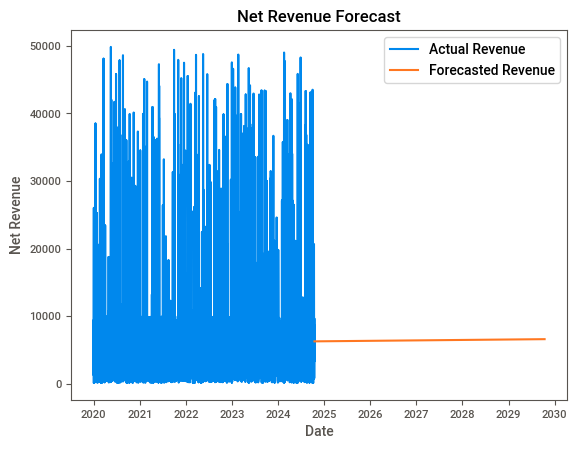

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from datetime import datetime, timedelta

# Assuming 'df' is your DataFrame with a 'Date' column and a 'Net Revenue' column

# 1. Prepare the data
df['Date'] = pd.to_datetime(df['Date'])  # Convert 'Date' column to datetime
df = df.sort_values(by=['Date'])  # Sort by date

# 2. Create features for the model (e.g., using days since the first date)
start_date = df['Date'].min()
df['DaysSinceStart'] = (df['Date'] - start_date).dt.days

# 3. Train a Linear Regression model
X = df[['DaysSinceStart']]
y = df['Net Revenue']
model = LinearRegression()
model.fit(X, y)

# 4. Forecast for the next 5 years
last_date = df['Date'].max()
future_dates = [last_date + timedelta(days=i) for i in range(1, 365 * 5 + 1)]
future_days_since_start = [(date - start_date).days for date in future_dates]
future_X = pd.DataFrame({'DaysSinceStart': future_days_since_start})
forecasted_revenue = model.predict(future_X)

# 5. Create a DataFrame for the forecast
forecast_df = pd.DataFrame({'Date': future_dates, 'Forecasted Revenue': forecasted_revenue})

# 6. Print or visualize the forecast
print(forecast_df)

# Optional: Plot the forecast
import matplotlib.pyplot as plt
plt.plot(df['Date'], df['Net Revenue'], label='Actual Revenue')
plt.plot(forecast_df['Date'], forecast_df['Forecasted Revenue'], label='Forecasted Revenue')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Net Revenue')
plt.title('Net Revenue Forecast')
plt.show()

Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - loss: 0.0153
Epoch 2/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0146
Epoch 3/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 0.0160
Epoch 4/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.0144
Epoch 5/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0148
Epoch 6/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 0.0161
Epoch 7/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - loss: 0.0143
Epoch 8/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.0149
Epoch 9/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0152
Epoch 10/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.0144
Epoch 11/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - loss: 0.0146
Epoch 12/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 0.0155
Epoch 13/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 0.0140
Epoch 14/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0167
Epoch 15/100
151/151 ━━━━━━━━━━━━━━━━━━━

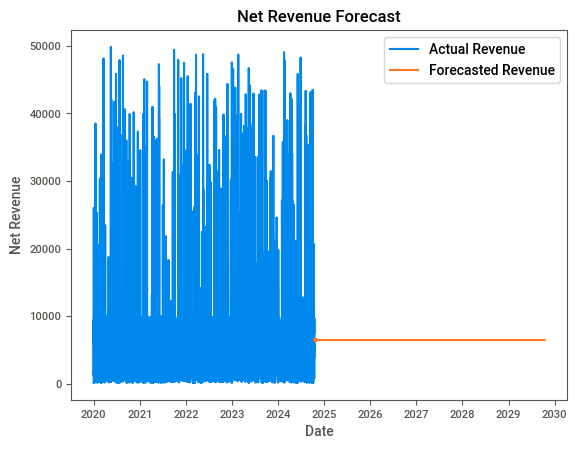

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
import matplotlib.pyplot as plt

# 1. Prepare the data
# Assuming 'df' is your DataFrame with 'Date' and 'Net Revenue' columns
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by=['Date'])
data = df['Net Revenue'].values.reshape(-1, 1)  # Reshape for scaling

# 2. Scale the data
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

# 3. Create training and testing datasets
train_size = int(len(data) * 0.8)  # 80% for training
train_data, test_data = data[0:train_size, :], data[train_size:len(data), :]

# 4. Create a dataset with lookback (e.g., 30 days)
def create_dataset(dataset, look_back=30):
    X, Y = [], []
    for i in range(len(dataset) - look_back - 1):
        a = dataset[i:(i + look_back), 0]
        X.append(a)
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

look_back = 30  # Adjust as needed
X_train, Y_train = create_dataset(train_data, look_back)
X_test, Y_test = create_dataset(test_data, look_back)

# 5. Reshape input to be [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# 6. Build the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(units=50))
model.add(Dense(1))

# 7. Compile and train the model
model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(X_train, Y_train, epochs=100, batch_size=32)  # Adjust epochs and batch size

# 8. Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# 9. Invert predictions to original scale
train_predict = scaler.inverse_transform(train_predict)
Y_train = scaler.inverse_transform([Y_train])
test_predict = scaler.inverse_transform(test_predict)
Y_test = scaler.inverse_transform([Y_test])

# 10. Forecast for the next 5 years
future_dates = pd.date_range(df['Date'].max() + pd.DateOffset(days=1), periods=365 * 5, freq='D')
future_data = []
for _ in range(365 * 5):
    last_lookback_days = data[-look_back:]
    future_predict = model.predict(last_lookback_days.reshape(1, look_back, 1))
    future_data.append(future_predict[0, 0])
    data = np.vstack([data, future_predict])

future_data = scaler.inverse_transform(np.array(future_data).reshape(-1, 1))

# 11. Create a DataFrame for the forecast
forecast_df = pd.DataFrame({'Date': future_dates, 'Forecasted Revenue': future_data.flatten()})

# 12. Plot the forecast
plt.plot(df['Date'], df['Net Revenue'], label='Actual Revenue')
plt.plot(forecast_df['Date'], forecast_df['Forecasted Revenue'], label='Forecasted Revenue')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Net Revenue')
plt.title('Net Revenue Forecast')
plt.show()